## Section 1: Data Loading & Exploration


      split  transactions  fraud_rate_pct
       full        590540             3.5
      train        354324             3.5
 validation         88581             3.5
calibration         88581             3.5
       test         59054             3.5


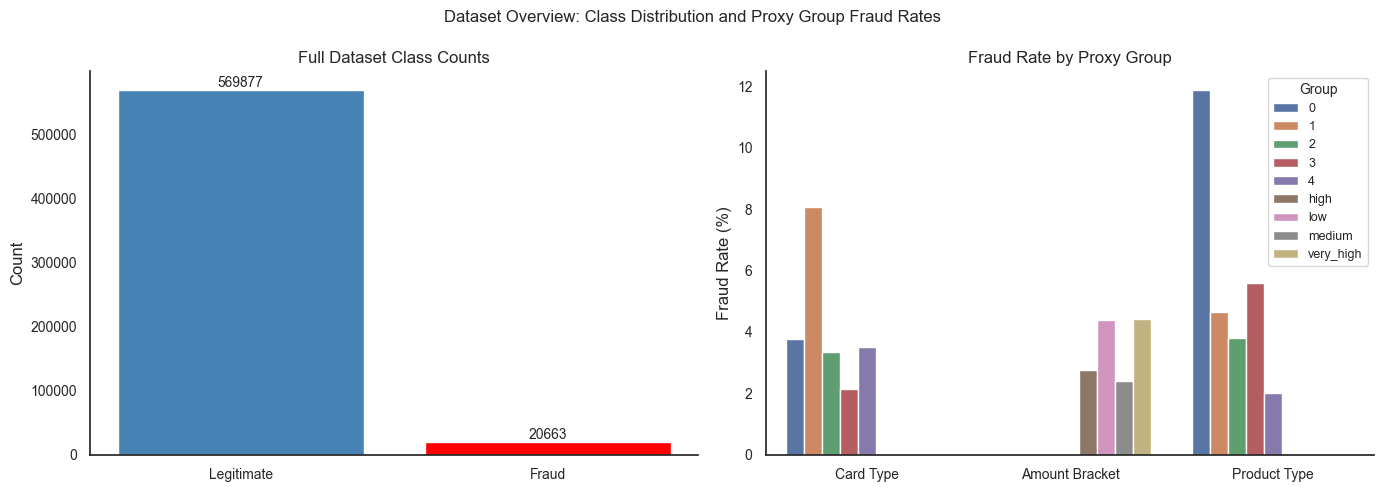


Saved plot to: outputs\plots\01_class_distribution.png


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data_loader import clean, get_proxy_groups, load_and_merge, split

sns.set_theme(style="white", font_scale=1.0)

transaction_path = Path("data/train_transaction.csv")
identity_path = Path("data/train_identity.csv")
plot_path = Path("outputs/plots/01_class_distribution.png")
plot_path.parent.mkdir(parents=True, exist_ok=True)

df = load_and_merge(transaction_path, identity_path)
df_clean, encoders = clean(df)
X_train, X_val, X_cal, X_test, y_train, y_val, y_cal, y_test = split(df_clean)
X_test_proxies = get_proxy_groups(X_test)

summary = pd.DataFrame(
    {
        "split": ["full", "train", "validation", "calibration", "test"],
        "n_transactions": [
            len(df_clean),
            len(X_train),
            len(X_val),
            len(X_cal),
            len(X_test),
        ],
        "fraud_rate": [
            df_clean["isFraud"].mean(),
            y_train.mean(),
            y_val.mean(),
            y_cal.mean(),
            y_test.mean(),
        ],
    }
)
summary["fraud_rate"] = (summary["fraud_rate"] * 100).round(2)
summary = summary.rename(
    columns={"n_transactions": "transactions", "fraud_rate": "fraud_rate_pct"}
)
print(summary.to_string(index=False))

proxy_rate_frames = []
proxy_specs = [
    ("card_type", "Card Type"),
    ("amount_bracket", "Amount Bracket"),
    ("product_type", "Product Type"),
]

for column, proxy_name in proxy_specs:
    rates = (
        pd.DataFrame({column: X_test_proxies[column], "isFraud": y_test})
        .groupby(column, observed=False)["isFraud"]
        .mean()
        .mul(100)
        .reset_index()
        .rename(columns={column: "group", "isFraud": "fraud_rate_pct"})
    )
    rates["proxy_variable"] = proxy_name
    proxy_rate_frames.append(rates)

proxy_rate_df = pd.concat(proxy_rate_frames, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Dataset Overview: Class Distribution and Proxy Group Fraud Rates", fontsize=12)

class_counts = df_clean["isFraud"].value_counts().reindex([0, 1], fill_value=0)
bars = axes[0].bar(
    ["Legitimate", "Fraud"],
    [class_counts.loc[0], class_counts.loc[1]],
    color=["steelblue", "red"],
)
axes[0].set_title("Full Dataset Class Counts", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)

for bar in bars:
    height = int(bar.get_height())
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

sns.barplot(
    data=proxy_rate_df,
    x="proxy_variable",
    y="fraud_rate_pct",
    hue="group",
    ax=axes[1],
)
axes[1].set_title("Fraud Rate by Proxy Group", fontsize=12)
axes[1].set_xlabel("")
axes[1].set_ylabel("Fraud Rate (%)", fontsize=12)
axes[1].legend(title="Group", fontsize=9, title_fontsize=10)

for ax in axes:
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"\nSaved plot to: {plot_path}")


## Section 2: Base Model & Calibration


In [2]:
from sklearn.metrics import roc_auc_score

from src.model import compute_ece, get_probs, temperature_scale, train_lgbm
from src.plotting import plot_reliability_diagram, plot_score_distribution

reliability_plot_path = Path("outputs/plots/02_reliability_diagram.png")
score_plot_path = Path("outputs/plots/02_score_distribution.png")

model = train_lgbm(X_train, y_train, X_val, y_val)
probs_val_raw = get_probs(model, X_val)
probs_test_raw = get_probs(model, X_test)

ece_before = compute_ece(y_val, probs_val_raw)
probs_val_cal, T = temperature_scale(probs_val_raw, y_val, probs_val_raw)
probs_cal_test, _ = temperature_scale(probs_val_raw, y_val, probs_test_raw)
ece_after = compute_ece(y_val, probs_val_cal)
val_auc = roc_auc_score(y_val, probs_val_raw)
best_iteration = model.best_iteration_

print(f"LightGBM trained | Best iteration: {best_iteration} | Val AUC: {val_auc:.4f}")
print(f"ECE before calibration: {ece_before:.4f}")
print(f"Temperature T: {T:.4f}")
print(f"ECE after calibration: {ece_after:.4f}")

plot_reliability_diagram(
    y_val,
    probs_val_raw,
    y_val,
    probs_val_cal,
    reliability_plot_path,
    temperature=T,
)
plot_score_distribution(y_test, probs_test_raw, probs_cal_test, score_plot_path)

print(f"\nSaved reliability diagram to: {reliability_plot_path}")
print(f"Saved score distribution plot to: {score_plot_path}")


c:\Users\dagxx\miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\dagxx\miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\dagxx\miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\dagxx\miniconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^

Training until validation scores don't improve for 50 rounds


[50]	valid_0's auc: 0.919265	valid_0's binary_logloss: 0.303007


[100]	valid_0's auc: 0.932582	valid_0's binary_logloss: 0.294114


[150]	valid_0's auc: 0.93902	valid_0's binary_logloss: 0.272204


...

[400]	valid_0's auc: 0.949915	valid_0's binary_logloss: 0.208465


[450]	valid_0's auc: 0.951202	valid_0's binary_logloss: 0.199545


[500]	valid_0's auc: 0.952187	valid_0's binary_logloss: 0.191229
Did not meet early stopping. Best iteration is:
[500]	valid_0's auc: 0.952187	valid_0's binary_logloss: 0.191229
Evaluated only: auc
Best iteration: 500
Best val AUC: 0.9522


LightGBM trained | Best iteration: 500 | Val AUC: 0.9522
ECE before calibration: 0.1260
Temperature T: 0.5762
ECE after calibration: 0.0789



Saved reliability diagram to: outputs\plots\02_reliability_diagram.png
Saved score distribution plot to: outputs\plots\02_score_distribution.png


## Section 3: Conformal Prediction Sets


In [3]:
from src.conformal import (
    compute_nonconformity_scores,
    compute_threshold,
    coverage_check,
    get_prediction_sets,
    get_three_zone_routing,
)
from src.plotting import plot_conformal_analysis

alpha_10 = 0.10
alpha_30 = 0.30
low_thresh = 0.05
high_thresh = 0.80
conformal_plot_path = Path("outputs/plots/03_conformal_analysis.png")

probs_cal = get_probs(model, X_cal)
nonconformity_scores = compute_nonconformity_scores(probs_cal, y_cal)

tau_10 = compute_threshold(nonconformity_scores, alpha=alpha_10)
tau_30 = compute_threshold(nonconformity_scores, alpha=alpha_30)

set_sizes_cal_10 = get_prediction_sets(probs_cal, tau_10)
set_sizes_test_10 = get_prediction_sets(probs_cal_test, tau_10)
coverage_10 = coverage_check(probs_cal_test, y_test, tau_10)

set_sizes_cal_30 = get_prediction_sets(probs_cal, tau_30)
set_sizes_test_30 = get_prediction_sets(probs_cal_test, tau_30)
coverage_30 = coverage_check(probs_cal_test, y_test, tau_30)

routing_conformal_test = get_three_zone_routing(
    probs_cal_test,
    tau_30,
    low_thresh=low_thresh,
    high_thresh=high_thresh,
)

pct_size1_10 = 100 * (set_sizes_test_10 == 1).mean()
pct_size2_10 = 100 * (set_sizes_test_10 == 2).mean()
pct_size1_30 = 100 * (set_sizes_test_30 == 1).mean()
pct_size2_30 = 100 * (set_sizes_test_30 == 2).mean()

zone_order = ["auto_approve", "auto_block", "auto_decide", "escalate"]
zone_counts = {zone: int((routing_conformal_test == zone).sum()) for zone in zone_order}
zone_pcts = {zone: 100 * zone_counts[zone] / len(routing_conformal_test) for zone in zone_order}

print("=== Conformal Routing Summary ===")
print(
    f"Alpha=0.10: τ̂={tau_10:.4f} | Set size 1: {pct_size1_10:.1f}% | Set size 2: {pct_size2_10:.1f}%"
)
print(
    f"Alpha=0.30: τ̂={tau_30:.4f} | Set size 1: {pct_size1_30:.1f}% | Set size 2: {pct_size2_30:.1f}%"
)
print()
print("Three-Zone Routing (α=0.30):")
print(
    f"  Auto-approve (prob < 0.05):  {zone_counts['auto_approve']} ({zone_pcts['auto_approve']:.1f}%)"
)
print(
    f"  Auto-block   (prob > 0.80):  {zone_counts['auto_block']} ({zone_pcts['auto_block']:.1f}%)"
)
print(
    f"  Auto-decide  (middle, conf): {zone_counts['auto_decide']} ({zone_pcts['auto_decide']:.1f}%)"
)
print(
    f"  Escalate     (middle, unc):  {zone_counts['escalate']} ({zone_pcts['escalate']:.1f}%)"
)
print()
print(f"Empirical coverage α=0.10: {coverage_10:.4f}")
print(f"Empirical coverage α=0.30: {coverage_30:.4f}")

plot_conformal_analysis(
    nonconformity_scores,
    y_cal,
    probs_cal_test,
    set_sizes_test_10,
    set_sizes_test_30,
    routing_conformal_test,
    tau_10,
    tau_30,
    conformal_plot_path,
    low_thresh=low_thresh,
    high_thresh=high_thresh,
)

print(f"\nSaved conformal analysis plot to: {conformal_plot_path}")


=== Conformal Routing Summary ===
Alpha=0.10: τ̂=0.9952 | Set size 1: 36.3% | Set size 2: 63.7%
Alpha=0.30: τ̂=0.9735 | Set size 1: 62.3% | Set size 2: 37.7%

Three-Zone Routing (α=0.30):
  Auto-approve (prob < 0.05):  40630 (68.8%)
  Auto-block   (prob > 0.80):  2691 (4.6%)
  Auto-decide  (middle, conf): 0 (0.0%)
  Escalate     (middle, unc):  15733 (26.6%)

Empirical coverage α=0.10: 0.9988
Empirical coverage α=0.30: 0.9958



Saved conformal analysis plot to: outputs\plots\03_conformal_analysis.png


## Section 4: Routing Strategies


In [ ]:
    import numpy as np

    from src.routing import (
        compute_system_metrics,
        simulate_analyst,
        strategy_capacity_aware,
        strategy_confidence_threshold,
        strategy_model_alone,
    )

    costs = {"auto": 0.1, "verify": 2.0, "escalate": 10.0}

    # Simulate one day: sample 10,000 transactions from test set
    # This represents realistic daily transaction volume
    np.random.seed(42)
    day_indices = np.random.choice(len(X_test), size=10000, replace=False)

    probs_day = probs_cal_test[day_indices]
    y_day = y_test.iloc[day_indices].values
    routing_day = routing_conformal_test[day_indices]

    print(f"Daily simulation: {len(probs_day)} transactions")
    print(f"Fraud cases today: {y_day.sum()} ({y_day.mean()*100:.1f}%)")
    print(f"Conformal escalation zone: {(routing_day == 'escalate').sum()} transactions")

    results_s1 = strategy_model_alone(probs_day, threshold=0.5)
    results_s2 = strategy_confidence_threshold(probs_day, low_thresh=0.05, high_thresh=0.80)

    daily_budget = int(0.40 * (routing_day == 'escalate').sum())
    print(f"Daily analyst budget: {daily_budget}")

    # Morning: lower fraud probability transactions arrive first
    # Afternoon: higher fraud probability transactions arrive later
    # This simulates realistic intraday fraud pattern
    morning_idx = np.where(probs_day <= np.median(probs_day))[0]
    afternoon_idx = np.where(probs_day > np.median(probs_day))[0]
    arrival_order = np.concatenate([morning_idx, afternoon_idx])

    results_s3 = strategy_capacity_aware(
        probs_day,
        y_day,
        routing_day,
        daily_budget=daily_budget,
        arrival_order=arrival_order,
    )

    sim_s1 = simulate_analyst(results_s1["decisions"], probs_day, y_day)
    sim_s2 = simulate_analyst(results_s2["decisions"], probs_day, y_day)
    sim_s3 = simulate_analyst(results_s3["decisions"], probs_day, y_day)

    metrics_s1 = compute_system_metrics(results_s1, sim_s1, y_day, probs_day, costs)
    metrics_s2 = compute_system_metrics(results_s2, sim_s2, y_day, probs_day, costs)
    metrics_s3 = compute_system_metrics(results_s3, sim_s3, y_day, probs_day, costs)

    print(
        f"Budget utilization: {results_s3['budget_used']}/{daily_budget} ({results_s3['budget_utilization']:.1%})"
    )

    table_rows = [
        ("Risk (error rate)", f"{metrics_s1['risk']:.4f}", f"{metrics_s2['risk']:.4f}", f"{metrics_s3['risk']:.4f}"),
        (
            "False Negative Rate",
            f"{metrics_s1['false_negative_rate']:.4f}",
            f"{metrics_s2['false_negative_rate']:.4f}",
            f"{metrics_s3['false_negative_rate']:.4f}",
        ),
        (
            "False Positive Rate",
            f"{metrics_s1['false_positive_rate']:.4f}",
            f"{metrics_s2['false_positive_rate']:.4f}",
            f"{metrics_s3['false_positive_rate']:.4f}",
        ),
        (
            "Escalation Rate",
            f"{metrics_s1['escalation_rate']:.4f}",
            f"{metrics_s2['escalation_rate']:.4f}",
            f"{metrics_s3['escalation_rate']:.4f}",
        ),
        (
            "Verify Rate",
            "0.0000",
            "0.0000",
            f"{results_s3['verify_rate']:.4f}",
        ),
        (
            "Budget Used / Total",
            "N/A",
            "N/A",
            f"{results_s3['budget_used']}/{results_s3['budget_total']}",
        ),
        (
            "Total Cost",
            f"{metrics_s1['total_cost']:.4f}",
            f"{metrics_s2['total_cost']:.4f}",
            f"{metrics_s3['total_cost']:.4f}",
        ),
        (
            "Cost per Correct",
            f"{metrics_s1['cost_per_correct']:.4f}",
            f"{metrics_s2['cost_per_correct']:.4f}",
            f"{metrics_s3['cost_per_correct']:.4f}",
        ),
    ]

    print()
    print("=== Strategy Comparison ===")
    print(f"{'Metric':<24} | {'Model Alone':<11} | {'Conf. Threshold':<15} | {'Capacity-Aware':<14}")
    print("-" * 80)
    for metric, s1, s2, s3 in table_rows:
        print(f"{metric:<24} | {s1:>11} | {s2:>15} | {s3:>14}")


Daily simulation: 10000 transactions
Fraud cases today: 346 (3.5%)
Conformal escalation zone: 2685 transactions
Daily analyst budget: 1074
Budget utilization: 880/1074 (81.9%)

=== Strategy Comparison ===
Metric                   | Model Alone | Conf. Threshold | Capacity-Aware
--------------------------------------------------------------------------------
Risk (error rate)        |      0.0655 |          0.0641 |         0.0371
False Negative Rate      |      0.1994 |          0.0954 |         0.1156
False Positive Rate      |      0.0607 |          0.0630 |         0.0343
Escalation Rate          |      0.0000 |          0.2685 |         0.0880
Verify Rate              |      0.0000 |          0.0000 |         0.1805
Budget Used / Total      |         N/A |             N/A |       880/1074
Total Cost               |   1000.0000 |      27581.5000 |     13141.5000
Cost per Correct         |      0.1070 |          2.9471 |         1.3648


## Section 4b: Analyst Simulation Verification


In [5]:
# Verify simulation worked correctly
print("=== Analyst Simulation Verification ===")
print(f"\nStrategy 2 (Conf. Threshold):")
print(f"  Transactions escalated: {(results_s2['decisions'] == 'escalate').sum()}")
print(f"  Of those, analyst errors made: {sim_s2['errors'][results_s2['decisions'] == 'escalate'].sum()}")
print(f"  Analyst error rate on escalated: {sim_s2['errors'][results_s2['decisions'] == 'escalate'].mean():.3f} (expected ~0.15)")

print(f"\nStrategy 3 (Capacity-Aware):")
print(f"  Transactions escalated: {(results_s3['decisions'] == 'escalate').sum()}")
print(f"  Transactions verified: {(results_s3['decisions'] == 'verify').sum()}")
print(f"  Analyst error rate on escalated: {sim_s3['errors'][results_s3['decisions'] == 'escalate'].mean():.3f} (expected ~0.15)")
print(f"  Verify catch rate on fraud: ", end="")

# Among verified transactions that are actually fraud, 
# how many were correctly blocked?
verify_mask = results_s3['decisions'] == 'verify'
fraud_verified = (verify_mask) & (y_day == 1)
if fraud_verified.sum() > 0:
    caught = (sim_s3['final_decisions'][fraud_verified] == 'block').mean()
    print(f"{caught:.3f} (expected ~0.60)")
else:
    print("no fraud in verify zone")

print(f"\nFinal decisions sample check:")
print(f"  Total correct (S3): {(~sim_s3['errors']).sum()} / {len(y_day)}")
print(f"  Total fraud in test day: {y_day.sum()}")
print(f"  Fraud correctly blocked (S3): {((sim_s3['final_decisions'] == 'block') & (y_day == 1)).sum()}")
print(f"  Fraud missed (S3): {((sim_s3['final_decisions'] == 'approve') & (y_day == 1)).sum()}")


=== Analyst Simulation Verification ===

Strategy 2 (Conf. Threshold):
  Transactions escalated: 2685
  Of those, analyst errors made: 415
  Analyst error rate on escalated: 0.155 (expected ~0.15)

Strategy 3 (Capacity-Aware):
  Transactions escalated: 880
  Transactions verified: 1805
  Analyst error rate on escalated: 0.147 (expected ~0.15)
  Verify catch rate on fraud: 0.628 (expected ~0.60)

Final decisions sample check:
  Total correct (S3): 9629 / 10000
  Total fraud in test day: 346
  Fraud correctly blocked (S3): 306
  Fraud missed (S3): 40


## Section 5: Evaluation & Fairness


In [6]:
import pandas as pd

from src.evaluation import (
    compute_capacity_trajectory,
    compute_complementarity_by_group,
    compute_fairness_metrics,
    compute_risk_coverage_curve,
)
from src.plotting import (
    plot_capacity_trajectory,
    plot_fairness_analysis,
    plot_risk_coverage_curve,
    plot_summary_dashboard,
)

risk_curve_path = Path("outputs/plots/05_risk_coverage_curve.png")
capacity_path = Path("outputs/plots/05_capacity_trajectory.png")
fairness_card_path = Path("outputs/plots/05_fairness_card_type.png")
fairness_amount_path = Path("outputs/plots/05_fairness_amount_bracket.png")
fairness_product_path = Path("outputs/plots/05_fairness_product_type.png")
dashboard_path = Path("outputs/plots/05_summary_dashboard.png")

# 5.1 Risk-Coverage Curve
curve_thresholds = np.linspace(0.01, 0.99, 100)
coverages_model, risks_model, _ = compute_risk_coverage_curve(probs_day, y_day, thresholds=curve_thresholds)
coverages_conf, risks_conf, _ = compute_risk_coverage_curve(probs_day, y_day, thresholds=curve_thresholds)
model_operating_coverage = np.array([1.0])
model_operating_risk = np.array([metrics_s1['risk']])
conf_operating_coverage = np.array([1.0 - metrics_s2['escalation_rate']])
conf_operating_risk = np.array([metrics_s2['risk'] / max(1.0 - metrics_s2['escalation_rate'], 1e-8)])
capacity_operating_coverage = np.array([1.0 - metrics_s3['escalation_rate']])
capacity_operating_risk = np.array([metrics_s3['risk'] / max(1.0 - metrics_s3['escalation_rate'], 1e-8)])
plot_risk_coverage_curve(
    [
        np.concatenate([coverages_model, model_operating_coverage]),
        np.concatenate([coverages_conf, conf_operating_coverage]),
        capacity_operating_coverage,
    ],
    [
        np.concatenate([risks_model, model_operating_risk]),
        np.concatenate([risks_conf, conf_operating_risk]),
        capacity_operating_risk,
    ],
    ["Model Alone", "Conf. Threshold", "Capacity-Aware"],
    risk_curve_path,
)

# 5.2 Capacity Trajectory
time_steps, shadow_prices, budget_remaining, cumulative_escalations, cumulative_verifications = compute_capacity_trajectory(results_s3)
plot_capacity_trajectory(
    time_steps,
    shadow_prices,
    budget_remaining,
    cumulative_escalations,
    cumulative_verifications,
    daily_budget,
    capacity_path,
)

# 5.3 Fairness Analysis
proxy_groups_day = X_test_proxies.iloc[day_indices].reset_index(drop=True)
decisions_df_s2 = pd.DataFrame({
    'routing_decision': results_s2['decisions'],
    'final_decision': sim_s2['final_decisions'],
})
decisions_df_s3 = pd.DataFrame({
    'routing_decision': results_s3['decisions'],
    'final_decision': sim_s3['final_decisions'],
})

fairness_outputs = {}
fairness_specs = [
    ('card_type', fairness_card_path),
    ('amount_bracket', fairness_amount_path),
    ('product_type', fairness_product_path),
]

for group_col, save_path in fairness_specs:
    fairness_s2 = compute_fairness_metrics(decisions_df_s2, y_day, proxy_groups_day, group_col)
    fairness_s3 = compute_fairness_metrics(decisions_df_s3, y_day, proxy_groups_day, group_col)
    fairness_outputs[group_col] = (fairness_s2, fairness_s3)
    plot_fairness_analysis(fairness_s2, fairness_s3, group_col, save_path)

# 5.4 Summary Dashboard
plot_summary_dashboard(results_s1, results_s2, results_s3, sim_s1, sim_s2, sim_s3, dashboard_path)

print("=== Fairness Summary ===")
for group_col in ['card_type', 'amount_bracket', 'product_type']:
    fairness_s2, fairness_s3 = fairness_outputs[group_col]
    disparity_s2 = fairness_s2['escalation_rate'].max() - fairness_s2['escalation_rate'].min()
    disparity_s3 = fairness_s3['escalation_rate'].max() - fairness_s3['escalation_rate'].min()
    print(f"Group: {group_col}")
    print(f"  Max escalation rate disparity (Conf. Threshold): {disparity_s2:.3f}")
    print(f"  Max escalation rate disparity (Capacity-Aware):  {disparity_s3:.3f}")
    print()


=== Fairness Summary ===
Group: card_type
  Max escalation rate disparity (Conf. Threshold): 0.090
  Max escalation rate disparity (Capacity-Aware):  0.058

Group: amount_bracket
  Max escalation rate disparity (Conf. Threshold): 0.146
  Max escalation rate disparity (Capacity-Aware):  0.080

Group: product_type
  Max escalation rate disparity (Conf. Threshold): 0.196
  Max escalation rate disparity (Capacity-Aware):  0.101

